# Loss Curves for Neural Networks
**Objectives**
- Analyze and interpret training and testing loss curves for tabular data.
- Identify common training issues such as overfitting, underfitting, and instability.
- Experiment with model hyperparameters and training parameters to improve performance.


---

The **UCI Adult Income dataset** is a tabular dataset used for binary classification tasks. The goal is to predict whether an individual's income exceeds $50,000 per year based on census data.

**Details**:
- **Features:** 14 attributes (e.g., age, education, occupation).
- **Target:** Binary class (income >50K or <=50K).
- **Size:** 32,561

**Main Tasks**:
1. Load and preprocess the dataset.
2. Split it into a training and test set.
3. Train a neural network and analyze the training/test loss curves.
4. Perform experiments to understand how model capacity and learning rate impact performance.


----

## Part 1: Data Preparation

Objectives:
1. Load the dataset using `pandas`.
2. Split the data into a training and test set (say, 90%/10%)
3. Prepare data for training and inference by adequately handling missing values, categorical features, and normalizing the data.



In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt 

from torch.optim import SGD
from torch.utils.data import DataLoader

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Available device: {device}")

Available device: mps


In [50]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
           "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
           "hours-per-week", "native-country", "income"]

data = pd.read_csv(url, names=columns, sep=r',\s*', engine='python', na_values="NA")


In [51]:
# your code starts here
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [52]:
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [53]:
data.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [54]:
for col in data.columns:
    print(f"\n----- {col} -----")
    print(data[col].unique())



----- age -----
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]

----- workclass -----
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

----- fnlwgt -----
[ 77516  83311 215646 ...  34066  84661 257302]

----- education -----
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

----- education-num -----
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]

----- marital-status -----
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

----- occupation -----
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair'

In [55]:
for col in data.columns:
    print(f"{col}: {data[col].nunique()} unika värden")


age: 73 unika värden
workclass: 9 unika värden
fnlwgt: 21648 unika värden
education: 16 unika värden
education-num: 16 unika värden
marital-status: 7 unika värden
occupation: 15 unika värden
relationship: 6 unika värden
race: 5 unika värden
sex: 2 unika värden
capital-gain: 119 unika värden
capital-loss: 92 unika värden
hours-per-week: 94 unika värden
native-country: 42 unika värden
income: 2 unika värden


In [56]:
print(data['workclass'].value_counts(), end = '\n\n')
print(data['education'].value_counts(), end = '\n\n')
print(data['marital-status'].value_counts(), end = '\n\n')
print(data['occupation'].value_counts(), end = '\n\n')
print(data['relationship'].value_counts(), end = '\n\n')
print(data['race'].value_counts(), end = '\n\n')
print(data['sex'].value_counts(), end = '\n\n')
print(data['native-country'].value_counts(), end = '\n\n')
print(data['income'].value_counts(), end = '\n\n')


workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial   

In [57]:
data = data.replace("?", "Unknown")


In [58]:
data["income"]

0        <=50K
1        <=50K
2        <=50K
3        <=50K
4        <=50K
         ...  
32556    <=50K
32557     >50K
32558    <=50K
32559    <=50K
32560     >50K
Name: income, Length: 32561, dtype: object

In [59]:
data["income"] = data["income"].map({
    "<=50K": 0,
    ">50K": 1
})
data["income"].value_counts()


income
0    24720
1     7841
Name: count, dtype: int64

In [60]:
data["sex"] = data["sex"].map({
    "Male": 1,
    "Female": 0
})
data["sex"].value_counts()


sex
1    21790
0    10771
Name: count, dtype: int64

In [61]:
# För varje möjlig kategoriskt värde, loopa och konstruera en ny kolumn enligt ovan

categorical_columns = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']

for column in categorical_columns:
    for value in set(data[column].values):
    
        onehotencode = [1 if x == value else 0 for x in data[column]]
        data[value] = onehotencode
    

#slutligen, droppa orginalkolumnen som vi inte längre behöver    

for column in categorical_columns:
    data = data.drop(columns=[column])

/var/folders/c7/mgs83rk93617s2n5004mpjzm0000gn/T/ipykernel_26487/1200656851.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[value] = onehotencode
/var/folders/c7/mgs83rk93617s2n5004mpjzm0000gn/T/ipykernel_26487/1200656851.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[value] = onehotencode
/var/folders/c7/mgs83rk93617s2n5004mpjzm0000gn/T/ipykernel_26487/1200656851.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Columns: 106 entries, age to Nicaragua
dtypes: int64(106)
memory usage: 26.3 MB


In [63]:

income_col = data["income"]
data = data.drop(columns=["income"])
data["income"] = income_col

data.columns

data

/var/folders/c7/mgs83rk93617s2n5004mpjzm0000gn/T/ipykernel_26487/2048277746.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["income"] = income_col


,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,Unknown,State-gov,Federal-gov,...,Thailand,Portugal,Greece,Vietnam,Philippines,Poland,El-Salvador,Holand-Netherlands,Nicaragua,income
0,39,77516,13,1,2174,0,40,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,50,83311,13,1,0,0,13,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,38,215646,9,1,0,0,40,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,53,234721,7,1,0,0,40,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,28,338409,13,0,0,0,40,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,257302,12,0,0,0,38,0,0,0,...,0,0,0,0,0,0,0,0,0,0
32557,40,154374,9,1,0,0,40,0,0,0,...,0,0,0,0,0,0,0,0,0,1
32558,58,151910,9,0,0,0,40,0,0,0,...,0,0,0,0,0,0,0,0,0,0
32559,22,201490,9,1,0,0,20,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [81]:
target_column = data.columns[-1]
feature_columns = data.columns[:-1]

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(data[feature_columns],         
                                                    data[target_column],
                                                    test_size=0.1, 
                                                    random_state=42)

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)


(29304, 105)
(29304,)
(3257, 105)
(3257,)


In [82]:
from sklearn.preprocessing import StandardScaler
import numpy as np

for column in feature_columns:                               # iterera över alla input features
    
    highest_value = max(np.abs(x_train[column]))    # hitta det, till absolutbeloppet, högsta värdet i aktuella kolumn i x_train
    
    
    # dela nu aktuell kolumn i x_train med det nyfunna högsta värdet
    
    x_train[column] = x_train[column] / highest_value 
    
    # dela nu även motsvarande kolumn i x_test med SAMMA nyfunna högsta värde (från x_train)
    
    x_test[column] = x_test[column] / highest_value

In [83]:

print("Kontrollerar skalning...\n")

for col in feature_columns:
    train_max = np.max(np.abs(x_train[col]))
    test_max = np.max(np.abs(x_test[col]))
    
    print(f"Kolumn: {col}")
    print(f"  Max abs i x_train: {train_max}")
    print(f"  Max abs i x_test : {test_max}")
    
    if np.isclose(train_max, 1.0):
        print("  ✔ x_train är korrekt skalad till 1")
    else:
        print("  ✘ x_train är INTE korrekt skalad")
        
    if test_max <= 1.0:
        print("  ✔ x_test ligger inom [-1, 1]\n")
    else:
        print("  ✘ x_test är större än 1 (kan vara OK men värt att dubbelkolla)\n")


Kontrollerar skalning...

Kolumn: age
  Max abs i x_train: 1.0
  Max abs i x_test : 1.0
  ✔ x_train är korrekt skalad till 1
  ✔ x_test ligger inom [-1, 1]

Kolumn: fnlwgt
  Max abs i x_train: 1.0
  Max abs i x_test : 0.6549139391326897
  ✔ x_train är korrekt skalad till 1
  ✔ x_test ligger inom [-1, 1]

Kolumn: education-num
  Max abs i x_train: 1.0
  Max abs i x_test : 1.0
  ✔ x_train är korrekt skalad till 1
  ✔ x_test ligger inom [-1, 1]

Kolumn: sex
  Max abs i x_train: 1.0
  Max abs i x_test : 1.0
  ✔ x_train är korrekt skalad till 1
  ✔ x_test ligger inom [-1, 1]

Kolumn: capital-gain
  Max abs i x_train: 1.0
  Max abs i x_test : 1.0
  ✔ x_train är korrekt skalad till 1
  ✔ x_test ligger inom [-1, 1]

Kolumn: capital-loss
  Max abs i x_train: 1.0
  Max abs i x_test : 0.587465564738292
  ✔ x_train är korrekt skalad till 1
  ✔ x_test ligger inom [-1, 1]

Kolumn: hours-per-week
  Max abs i x_train: 1.0
  Max abs i x_test : 1.0
  ✔ x_train är korrekt skalad till 1
  ✔ x_test ligger 

In [84]:
x_train = torch.from_numpy(np.array(x_train)).type(torch.FloatTensor)
y_train = torch.from_numpy(np.array(y_train)).type(torch.FloatTensor).reshape([-1,1])

x_test = torch.from_numpy(np.array(x_test)).type(torch.FloatTensor)
y_test = torch.from_numpy(np.array(y_test)).type(torch.FloatTensor).reshape([-1,1])

In [85]:
x_train = x_train.to(device)
y_train = y_train.to(device)

x_test = x_test.to(device)
y_test = y_test.to(device)



In [86]:
training_set = list(zip(x_train, y_train))             # lägg ihop träningsdatan så att vi direkt kan skicka in i dataloader
test_set = list(zip(x_test, y_test))                   # ditto för testdatan

---

## Part 2: Build and Train the Model

**Initial Model Architecture**:


- *Input layer:* Size matches the number of features after encoding.
- *Hidden layers:*
  - Hidden Layer 1: 8 units, ReLU activation.
  - Hidden Layer 2: 8 units, ReLU activation.
- *Output layer:* 1 unit (binary classification), Sigmoid activation.


**Loss Function and Optimizer**:
- Loss: Binary Cross-Entropy Loss (`BCELoss`).
- Optimizer: SGD with a learning rate of 0.001.

**Training**:
- Train the model for 20 epochs.
- Record (store) the training and test losses at each epoch.


In [87]:
# your code here
# hint: recall how we did this previously
class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, 8)
        self.fc2 = nn.Linear(8, 8)
        self.fc3 = nn.Linear(8, 1)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
                  
        return x

In [88]:
print(x_train.shape)
print(x_test.shape)


torch.Size([29304, 105])
torch.Size([3257, 105])


In [96]:
input_size = 105
batch_size = 16
epochs = 20
learning_rate = 0.001

model = NeuralNetwork(input_size)
model = model.to(device)                         # vi skickar över modellen till gpu - om tillgänglig

model

NeuralNetwork(
  (fc1): Linear(in_features=105, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [97]:
# ----------------------------------------------------------------------------------------------------------------
#    initera modell, loss_function, optimizer & dataloader


#model = NeuralNetwork(input_size)
model = model.to(device)                                  # förbered modellen för GPU

optimizer = SGD(model.parameters(), lr = learning_rate)
loss_function = torch.nn.BCELoss()

train_dataloader = DataLoader(training_set,                 
                              batch_size = batch_size,       
                              shuffle=True)


# ----------------------------------------------------------------------------------------------------------------
#    träna



batch_train_losses = []

epoch_train_losses = []
epoch_evaluation_losses = []

for i in range(epochs):
    
    model.train()

    running_loss = 0
    
    for batch in train_dataloader:
        
        y_true = batch[1]
        input_features = batch[0]
        
        y_pred=model(input_features)
        loss=loss_function(y_pred, y_true)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        batch_loss = loss.item()
        batch_train_losses.append(batch_loss)
    
    epoch_average_loss = np.average(batch_train_losses[-len(train_dataloader):])
    epoch_train_losses.append(epoch_average_loss)

# ----------------------------------------------------------------------------------------------------------------
#   evalueringssektion 

    model.eval()
    
    y_true = y_test
    input_features = x_test
    
    y_pred = model(input_features)
    loss = loss_function(y_pred, y_true)
    
    evaluation_loss = loss.item()
    epoch_evaluation_losses.append(evaluation_loss)




---

## Part 3: Visualize and Interpret Loss Curves

**Tasks**:
1. Plot the training and test loss curves.
2. Answer the following questions:
   - Is the model underfitting, overfitting, or neither? Provide evidence.
   - If overfitting occurs, at what epoch does it begin?
   - What can you infer about the model's performance from the loss curves?

modellen varken overfittar eller underfittar när man kolla på plotten däremot behövs det mer träning.

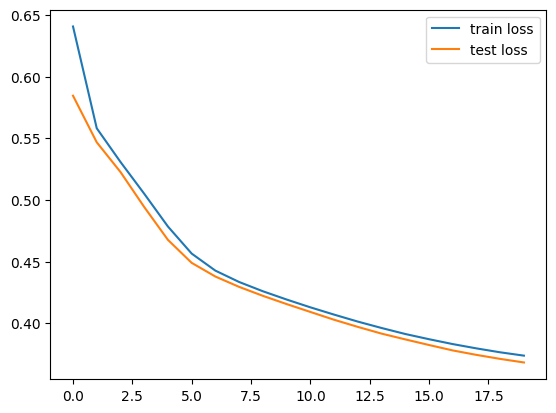

In [99]:
# your code here
plt.plot(epoch_train_losses, label = 'train loss')
plt.plot(epoch_evaluation_losses, label = 'test loss')
plt.legend()

plt.show()

---

## Part 4: Experimentation with Hyperparameters

**Experiment**: Varying model capacity
- Now train models with different hidden layer sizes (width & depth):
  - **Smaller model:** 
    - Try architectures will LESS representation capacity than we had initially
  - **Larger model:** 
    - Try architectures will MORE representation capacity than we had initially

- Train each of those architectures, with the same initial learning rate, 20 epochs each and plot their loss curves.

**Questions:**
1. How does changing the model size affect training and test loss?
2. What interesting findings have you found? Prepare to present and share with your classmates (just show the loss curves and explain your findings).

In [75]:
# your code here

---
## Part 5: Experimentation with learning rate


**Experiment**: Periodic reduction of learning rate
- During class we learned that dropping the learning rate, after a period of training, could lead to better results. Can we try to replicate that?

**Question:**
1. Did you succeed? If so, why did it work?


In [76]:
# your code here